In [10]:
import os
import numpy as np
import scipy
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix, bsr_matrix
from scipy.optimize import nnls, least_squares
from scipy.linalg import circulant


from util.Processing import discretize, td_nnlsr_deconvolve

In [11]:
mV_per_ADC = 1000. / 4096.
bits = 8
tstep = 12e-9  # Sampling rate in seconds (40 MHz)

In [12]:
for file in os.listdir('.'):
    if 'txt' not in file:
        continue
        
    real_trace = np.loadtxt(file, skiprows=1) 
    time = real_trace[:, 0]  # Relative time in µs
    adc = real_trace[:, 1]  # ADC amplitudes
    
    plt.figure(figsize=(5,3))
    plt.plot(time*1E6, adc * mV_per_ADC)
    plt.xlabel('Microseconds')
    plt.ylabel('mV')
    plt.title(file)
    # plt.ylim(0, 250)
    

84 165


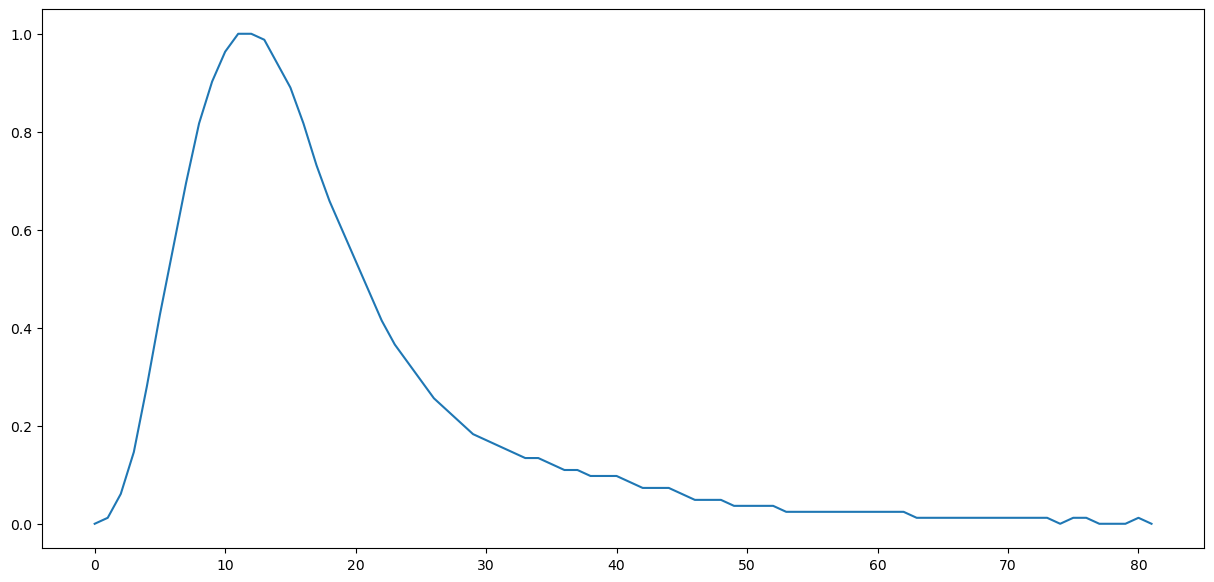

In [13]:
pulse = np.loadtxt('data/NaI_trace_pulse_220726_045157_buffer_0.txt', skiprows=1)[:, 1]
mode = pulse[0]
index = np.arange(pulse.size)
start = index[pulse != mode][0] - 1 # one before first non-mode
end = index[pulse != mode][-1] + 1 # one after last non-mode
pulse = pulse[start:end+1]
pulse = pulse - np.min(pulse)
print(start, end)

pulse /= np.max(pulse)

plt.plot(pulse)

In [14]:
# Prepare the real trace for NNLSR
real_trace = np.loadtxt('data/NaI_trace_filtered_220726_045157_buffer_0.txt', skiprows=1) 
time = real_trace[:, 0]  # Relative time in µs
adc = real_trace[:, 1]  # ADC amplitudes

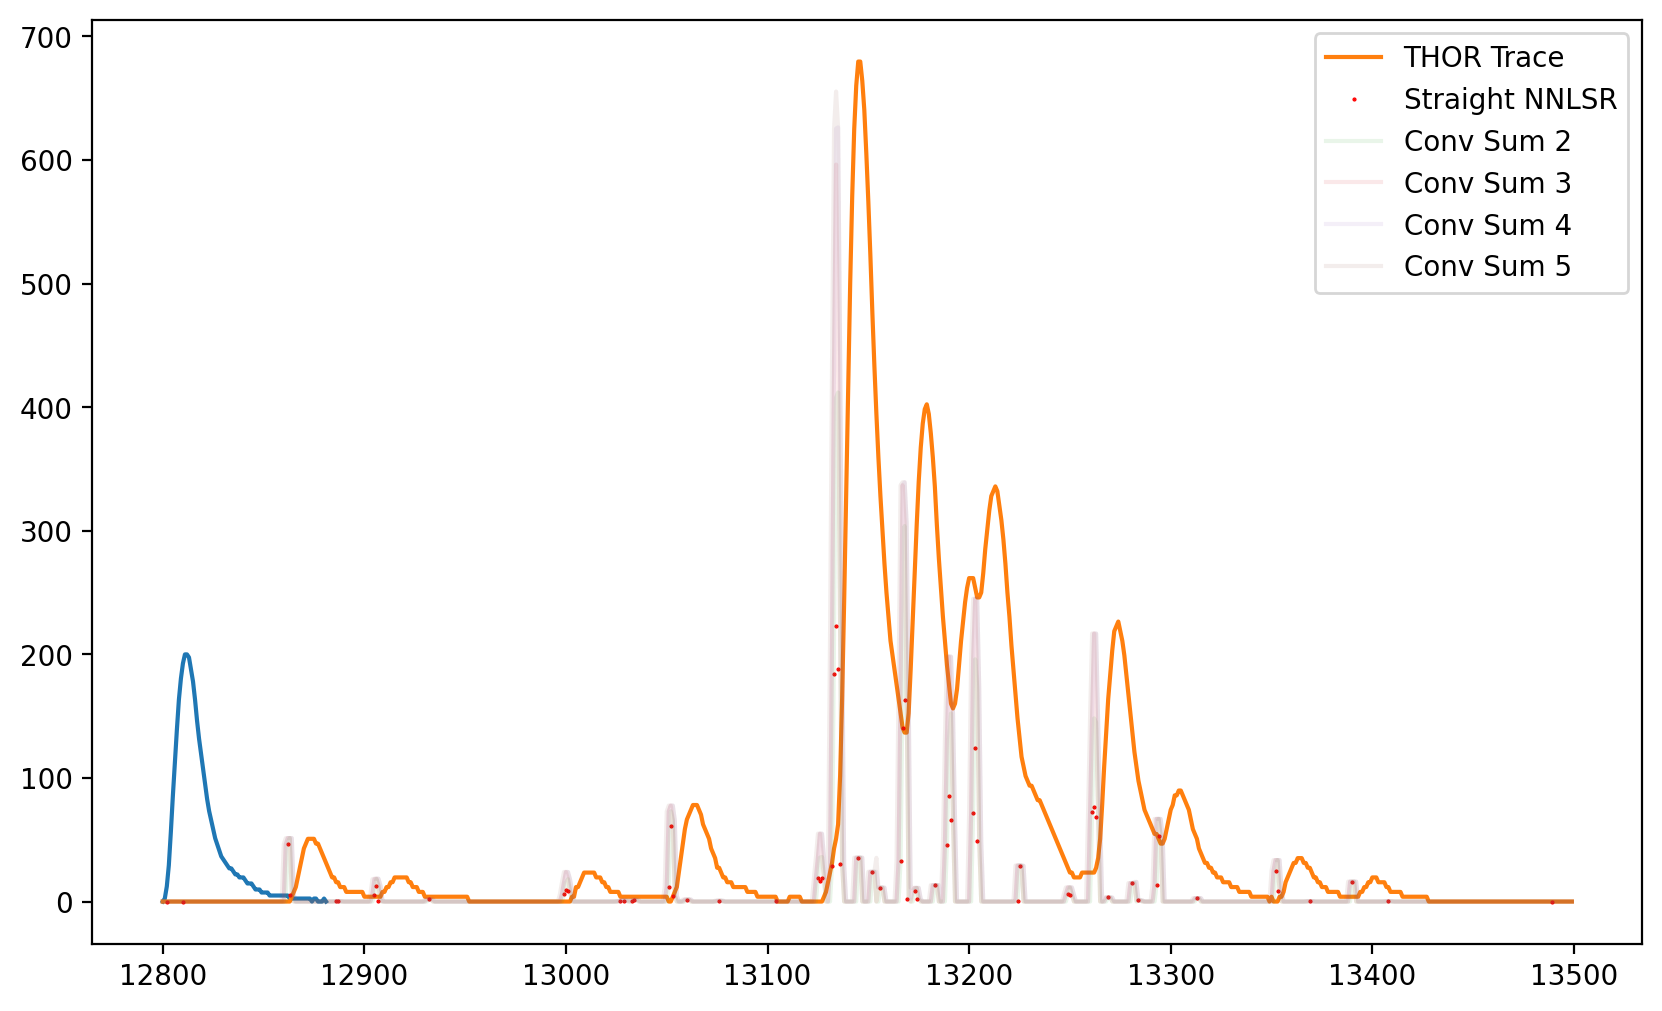

In [15]:
# Window
start = 12800
end = 13500
# start = 0
# end = adc.size
deconvolve = True

trace = adc.copy()[start:end]
index = np.arange(start, end)

base_est, _ = scipy.stats.mode(trace, keepdims=True)
trace -= base_est
trace *= mV_per_ADC


plt.figure(figsize=(10, 6), dpi=200)
plt.plot(index[:pulse.size], pulse * 200)
plt.plot(index, trace, label='THOR Trace')

if deconvolve:
    nnlsr_deconv = td_nnlsr_deconvolve(trace, pulse)  
    
    nnlsr_gt0 = nnlsr_deconv > 0
    plt.plot(index[nnlsr_gt0], nnlsr_deconv[nnlsr_gt0], color='red', marker='.', markersize=1, linestyle='', label='Straight NNLSR')
    
    for c in range(2,6):
        conv = np.convolve(nnlsr_deconv, np.ones(c), mode='same')
        plt.plot(index, conv, label='Conv Sum {}'.format(c), alpha=.1)
    
    # section_index = np.arange(nnlsr_deconv.size)
    # index_gt0 = section_index[nnlsr_gt0]
    # diff_nonzero = np.diff(index_gt0)
    # print(diff_nonzero)
        
    # groups = []
    # group = diff_nonzero[0] == 1
    # print(group)
    # group_start = 0
    # for i, diff in enumerate(diff_nonzero):
    #     if i == diff_nonzero.size-1:
    #         if group:
    #             groups.append(index_gt0[np.arange(group_start, i+1)])
    #     elif group:
    #         if diff_nonzero[i] != 1:
    #             groups.append(index_gt0[np.arange(group_start, i+1)])
    #             group = False
    #     else:
    #         if diff_nonzero[i] == 1:
    #             group_start = i
    #             group = True
    #             
    # print(groups)
    # summed_index = []
    # summed = []
    # for group in groups:  
    #     # print(group)
    #     # print(section_index[group], np.sum(trace[section_index[group]]))
    #     # print()
    #     
    #     summed_index.append(section_index[group][0] + index[0])       
    #     summed.append(np.sum(trace[section_index[group]]))
    #     
    # plt.plot(summed_index, summed, color='green', marker='.', markersize=6, linestyle='', label='Contiguous Summed')
    
plt.legend()
    
    

In [19]:
# Window
start = 13100
end = 13350
# start = 20000
# end = 23000
# start = 0
# end = adc.size
deconvolve = True

trace = adc.copy()[start:end]
index = np.arange(start, end)

base_est, _ = scipy.stats.mode(trace, keepdims=True)
trace -= base_est
trace *= mV_per_ADC


if deconvolve:
    def nnlsr_residual(x, C, trace):
        out = trace - C @ x
        return out
    
    c = np.concatenate((pulse, np.zeros(trace.size - pulse.size)), axis=0)
    circ = circulant(c)
    # C_jac = csc_matrix(lil_matrix(C)) # note that this shape should match the sparsity operations so no transpose...
    sparsity = csc_matrix(lil_matrix((circ != 0)))
    C = csc_matrix(lil_matrix(circ))
    x0 = np.ones(trace.size)
    
    solution = least_squares(fun=nnlsr_residual,
                             jac='cs',
                             method='trf', # use with bounds!
                             bounds=[0, np.inf],
                             args=(C, trace),
                             x0=x0,
                             x_scale=10,
                             diff_step=1,
                             loss = 'linear',
                             jac_sparsity=C, # Speeds things up significantly with sparse matrices
                             ftol=1E-15,
                             max_nfev=1000,
                             verbose=2
                             )
    deconv = solution.x       

    

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.7226e+06                                    8.21e+03    
       1              2         3.6649e+06      1.06e+06       2.36e+01       7.32e+03    
       2              3         2.0236e+06      1.64e+06       4.72e+01       5.50e+03    
       3              4         5.6516e+05      1.46e+06       9.43e+01       1.28e+04    
       4              5         2.9427e+05      2.71e+05       6.11e+01       9.42e+03    
       5              6         1.4266e+05      1.52e+05       4.04e+01       2.80e+03    
       6              7         6.6950e+04      7.57e+04       5.77e+01       1.86e+03    
       7              8         4.9481e+04      1.75e+04       1.43e+01       3.01e+03    
       8              9         3.8814e+04      1.07e+04       3.42e+01       2.55e+03    
       9             10         3.3901e+04      4.91e+03       1.70e+01       2.30e+03    

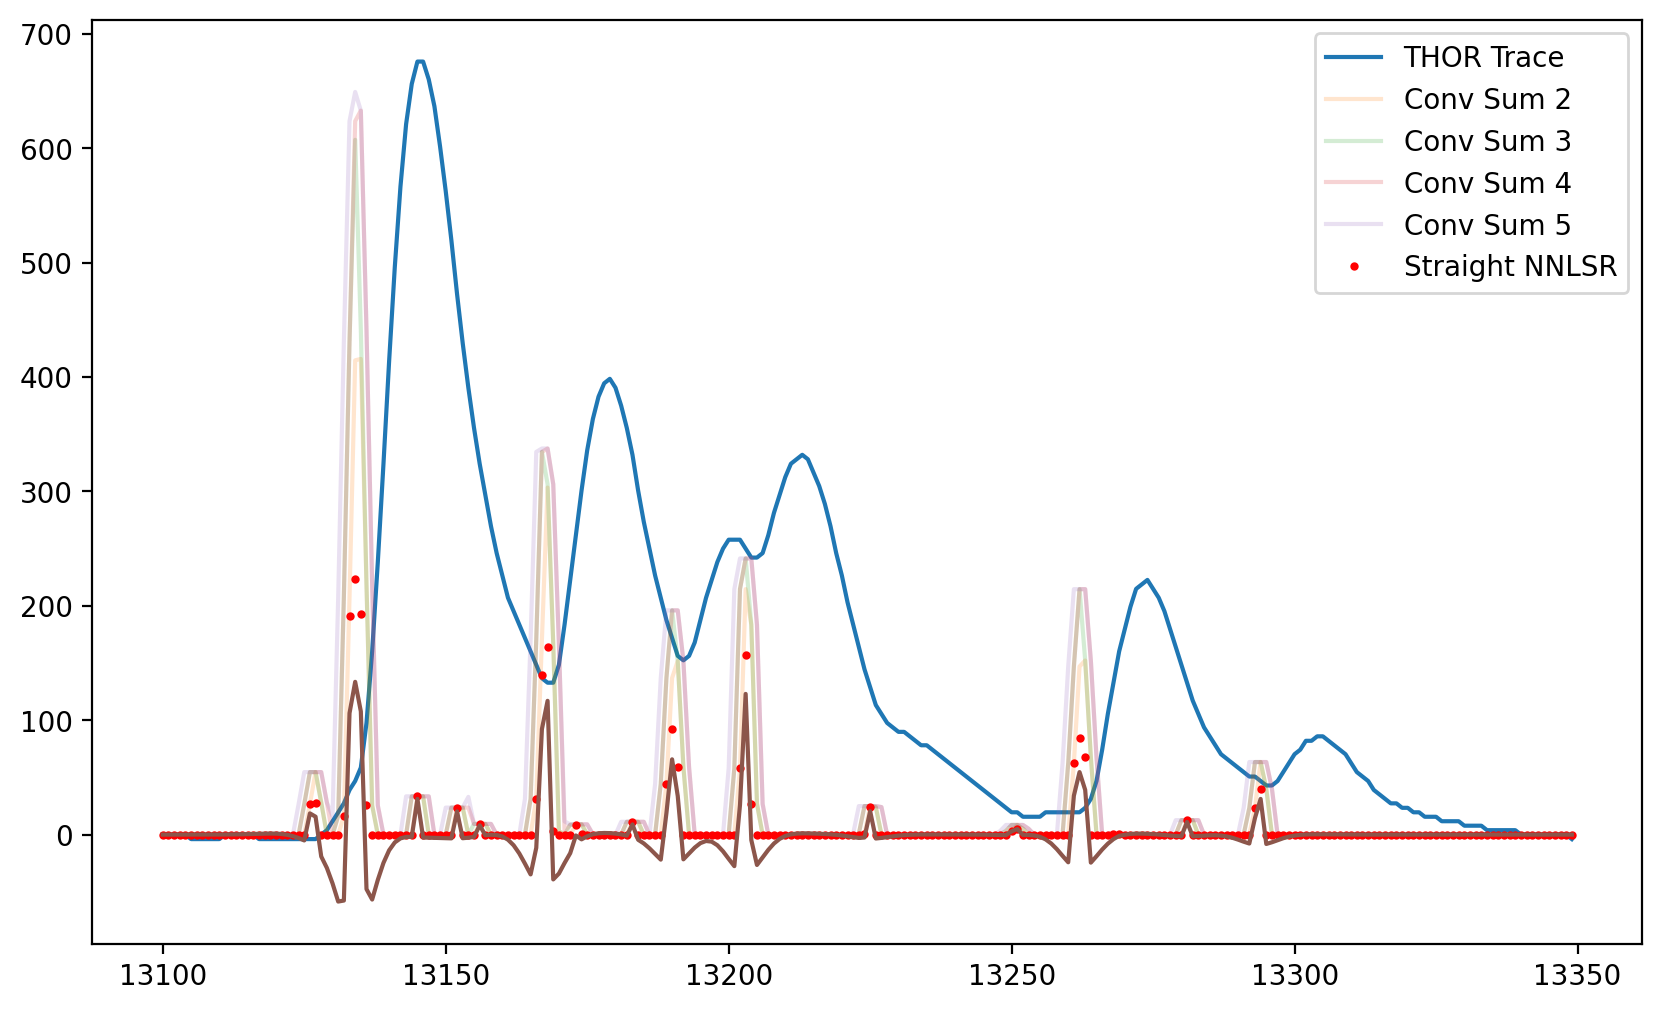

In [28]:
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(index, trace, label='THOR Trace')

nnlsr_gt0 = deconv > 0

for c in range(2,6):
    conv = np.convolve(deconv, np.ones(c), mode='same')
    plt.plot(index, conv, label='Conv Sum {}'.format(c), alpha=.2)
    
plt.plot(index[nnlsr_gt0], deconv[nnlsr_gt0], color='red', marker='.', markersize=4, linestyle='', label='Straight NNLSR')
 
deconv2 = deconv - scipy.ndimage.gaussian_filter1d(deconv, sigma=5, mode='reflect')
deconv2 = deconv2 - scipy.ndimage.gaussian_filter1d(deconv2, sigma=3, mode='reflect')
plt.plot(index, deconv2)

plt.legend()